In [73]:
import pandas as pd
import numpy as np

In [74]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [75]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [77]:
df.shape

(7043, 21)

In [78]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [83]:
# 1. Fix TotalCharges by converting spaces to NaN and casting to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [84]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [85]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [86]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).drop(columns=['customerID'], errors='ignore').columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# We exclude 'customerID' since it's just a unique identifier, not a feature

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [87]:
df[num_cols].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [88]:
# Step 1: Explore the variety in categorical columns
# This helps us decide how to encode them later
df[cat_cols].nunique().sort_values(ascending=False)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [89]:
df[cat_cols].nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [90]:
#visualizing num_cols distribution
#modified prompt using more parameters to improve styling

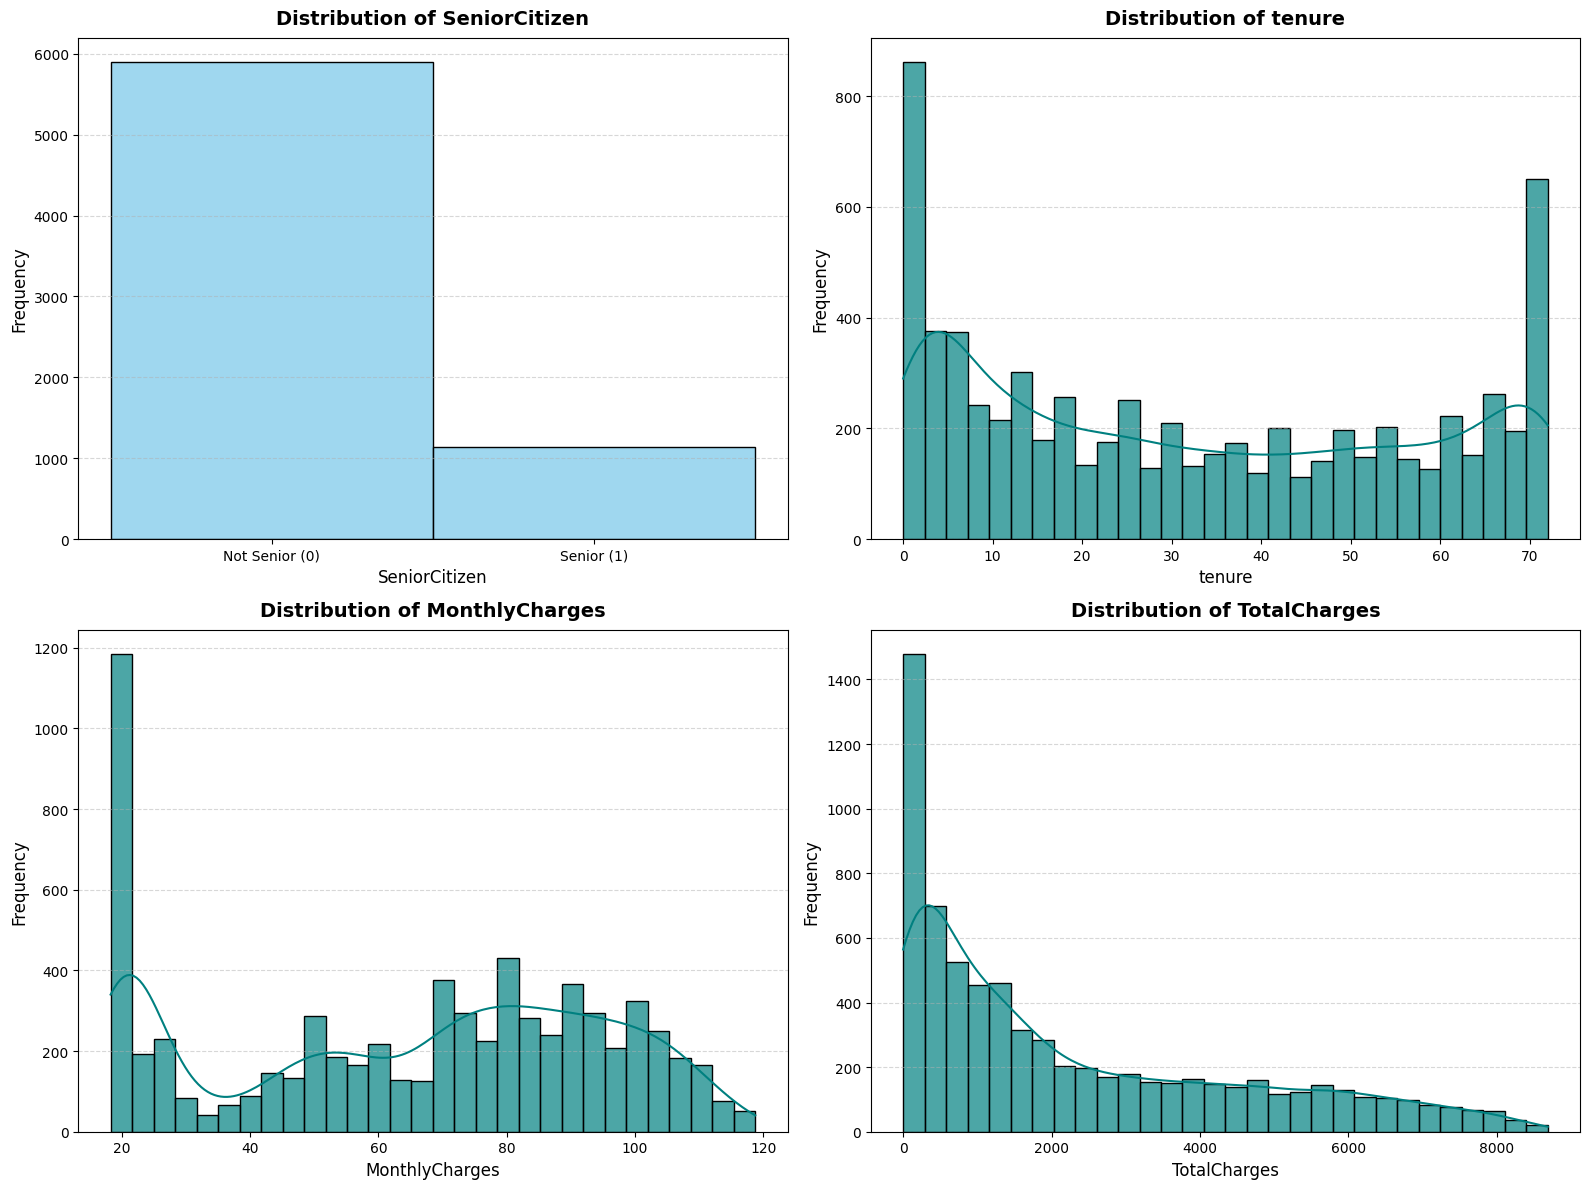

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a 2x2 subplot grid to display all 4 numerical columns together
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flattens the 2x2 matrix into a 1D array for easy looping

for i, col in enumerate(num_cols):
    # 2. REQUIRED MODIFICATION: Handle the binary column differently than continuous ones
    if col == 'SeniorCitizen':
        # Use discrete bars without a continuous KDE curve for binary data
        sns.histplot(data=df, x=col, ax=axes[i], discrete=True, color='skyblue', alpha=0.8)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Not Senior (0)', 'Senior (1)'])
    else:
        # Use your original design (30 bins + KDE) for continuous columns
        sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='teal', alpha=0.7)

    # 3. Apply your consistent styling to each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].grid(axis='y', alpha=0.5, linestyle='--')

# 4. Clean up spacing so titles and axes labels do not overlap
plt.tight_layout()
plt.show()

In [92]:
df_clean = df.copy()

continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in continuous_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_lower = (df_clean[col] < lower_bound).sum()
    outliers_upper = (df_clean[col] > upper_bound).sum()

    print(f"{col}: Found {outliers_lower} lower outliers and {outliers_upper} upper outliers.")

    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print("\nOutlier treatment complete! Capped values stored in 'df_clean'.")

tenure: Found 0 lower outliers and 0 upper outliers.
MonthlyCharges: Found 0 lower outliers and 0 upper outliers.
TotalCharges: Found 0 lower outliers and 0 upper outliers.

Outlier treatment complete! Capped values stored in 'df_clean'.


In [93]:
df_encoded = df_clean.copy()

binary_cols = [col for col in cat_cols if df_encoded[col].nunique() == 2]
multiclass_cols = [col for col in cat_cols if df_encoded[col].nunique() > 2]

# 2. Apply One-Hot Encoding to Multi-class columns
# drop_first=True prevents multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=multiclass_cols, drop_first=True, dtype=int)

# 3. Apply Binary 0/1 Encoding to the remaining 2-value categorical columns
for col in binary_cols:
    # This dynamically maps whatever the two categories are to 0 and 1
    labels = df_encoded[col].unique()
    mapping = {labels[0]: 0, labels[1]: 1}
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"Encoded {col}: {mapping}")

print("\nTransformation Complete!")
df_encoded.head()

Encoded gender: {'Female': 0, 'Male': 1}
Encoded Partner: {'Yes': 0, 'No': 1}
Encoded Dependents: {'No': 0, 'Yes': 1}
Encoded PhoneService: {'No': 0, 'Yes': 1}
Encoded PaperlessBilling: {'Yes': 0, 'No': 1}
Encoded Churn: {'No': 0, 'Yes': 1}

Transformation Complete!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,0,0,1,0,0,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,1,0,34,1,1,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,1,0,2,1,0,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,1,0,45,0,1,42.30,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,1,0,2,1,0,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0


In [95]:
# 'Churn' is our target variable, the rest are features
X = df_encoded.drop(columns=['Churn', 'customerID'], errors='ignore')
y = df_encoded['Churn']

In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")


Training set size : 5634 samples
Testing set size : 1409 samples


In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])


Training set size: 5634 samples
Testing set size: 1409 samples
Scaling complete.


## 4. Model Training and Evaluation
We use a Random Forest Classifier to predict customer churn based on the processed features.

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7927608232789212

Confusion Matrix:
 [[928 107]
 [185 189]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



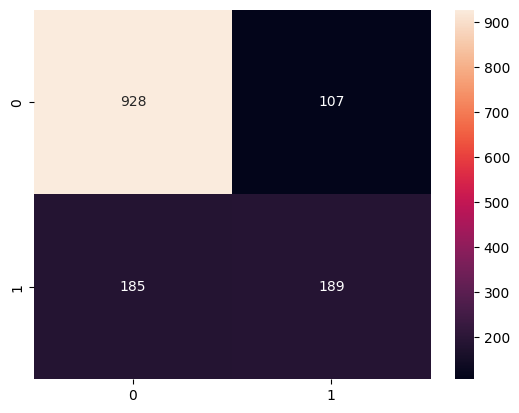

In [104]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

## 5. Feature Importance
Let's visualize which features are most important for predicting churn.

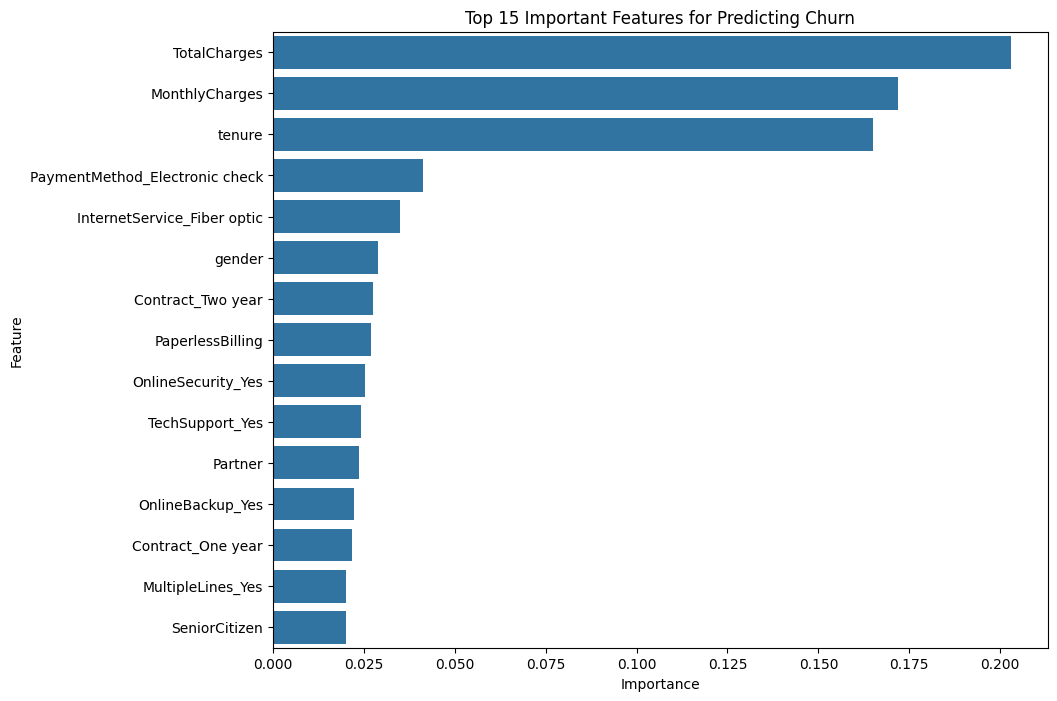

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Important Features for Predicting Churn')
plt.show()